# AI-Based Loan Recovery Prediction

## SHAP Explainability Analysis

## 1 )  Import Required Libraries

In [1]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 2 ) Load Final ML Dataset

In [2]:
# LOAD FINAL ML DATASET

loan_recovery_data = pd.read_csv( 'final_ml_dataset.csv')

loan_recovery_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_FREQ,ORGANIZATION_TYPE_FREQ,CREDIT_ANNUITY_RATIO,TOTAL_INQUIRIES,RECENT_INQUIRY_RATIO
0,100002,1,1,1,0,1,0,202500.0,406597.5,24700.5,...,1,0,0,0,0,55186.0,67992,16.460438,1.0,0.0
1,100003,0,1,0,0,0,0,270000.0,1293502.5,35698.5,...,1,0,0,0,0,27570.0,8893,36.233070,0.0,0.0
2,100004,0,0,1,1,1,0,67500.0,135000.0,6750.0,...,1,0,0,0,0,55186.0,10404,19.997037,0.0,0.0
3,100006,0,1,0,0,1,0,135000.0,312682.5,29686.5,...,1,0,0,0,0,55186.0,67992,10.532463,1.0,0.0
4,100007,0,1,1,0,1,0,121500.0,513000.0,21865.5,...,1,0,0,0,0,27570.0,85,23.460545,0.0,0.0


## 3 ) Separate Features and Target

In [3]:
# SEPARATE FEATURES AND TARGET

X = loan_recovery_data.drop(columns=['TARGET'])

y = loan_recovery_data['TARGET']

print(f'Feature Shape : {X.shape}')

print(f'Target Shape  : {y.shape}')

Feature Shape : (307511, 111)
Target Shape  : (307511,)


- Successfully separated input features (X) and target variable (y) for machine learning model development.
- The feature dataset contains 111 engineered and processed features after cleaning, encoding, and feature selection.
- TARGET variable represents borrower default risk classification for supervised learning.


## 4 ) Load Optimized LightGBM Model

In [4]:
# LOAD OPTIMIZED LIGHTGBM MODEL

optimized_lgbm = joblib.load('optimized_lightgbm_model.pkl')

print('Optimized LightGBM Model Loaded Successfully!')

Optimized LightGBM Model Loaded Successfully!


- Successfully loaded the optimized LightGBM model for inference and evaluation.
- The trained model contains learned patterns from engineered financial, behavioral, bureau, and social-risk features.
- Loading the serialized model enables reproducible prediction workflows without retraining.
- The optimized LightGBM model is now ready for prediction, evaluation, SHAP explainability, and deployment tasks.

## 5 ) Create Sample Data for SHAP Analysis

In [5]:
# ============================================================
# CREATE SAMPLE DATA FOR SHAP ANALYSIS
# ============================================================

X_sample = X.sample(n=3000, random_state=42)

print(f'SHAP Sample Shape : {X_sample.shape}')

SHAP Sample Shape : (3000, 111)


- Created a representative sample dataset for SHAP explainability analysis to improve computational efficiency.
- Sampling helps reduce SHAP computation time while preserving overall feature distribution patterns.
- The sample dataset contains 1000 observations and 111 engineered features.
- Using a smaller subset enables faster model interpretability analysis and visualization generation.

## 6 ) Create SHAP Explainer

In [8]:
# ============================================================
# EXTRACT LIGHTGBM MODEL FROM PIPELINE
# ============================================================

lgbm_model = optimized_lgbm.named_steps['model']

# Create SHAP Explainer

explainer = shap.TreeExplainer(lgbm_model)

# Generate SHAP Values

shap_values = explainer.shap_values(X_sample)

print('SHAP Explainer Created Successfully!')

SHAP Explainer Created Successfully!


- Successfully created a SHAP TreeExplainer for interpreting the optimized LightGBM model.
- The explainer computes feature contribution values to understand how individual features influence model predictions.
- SHAP analysis enables transparent and explainable AI interpretation for credit risk and recovery prediction.
- The generated SHAP values are now ready for summary plots, feature importance analysis, and local prediction explanations.

## 7 ) Check SHAP Value Shape

In [9]:
# ============================================================
# CHECK SHAP VALUES SHAPE
# ============================================================

print(f'SHAP Values Shape : {np.array(shap_values).shape}')

SHAP Values Shape : (3000, 111)


- Verified the dimensionality and structure of generated SHAP values for the sampled dataset.
- SHAP values were successfully generated for 1000 observations across 111 engineered features.
- The SHAP output shape confirms proper alignment between model input features and explainability results.
- The explainability pipeline is now ready for SHAP summary plots, feature importance visualization, and local prediction interpretation.

## 8 ) SHAP Summary Plot

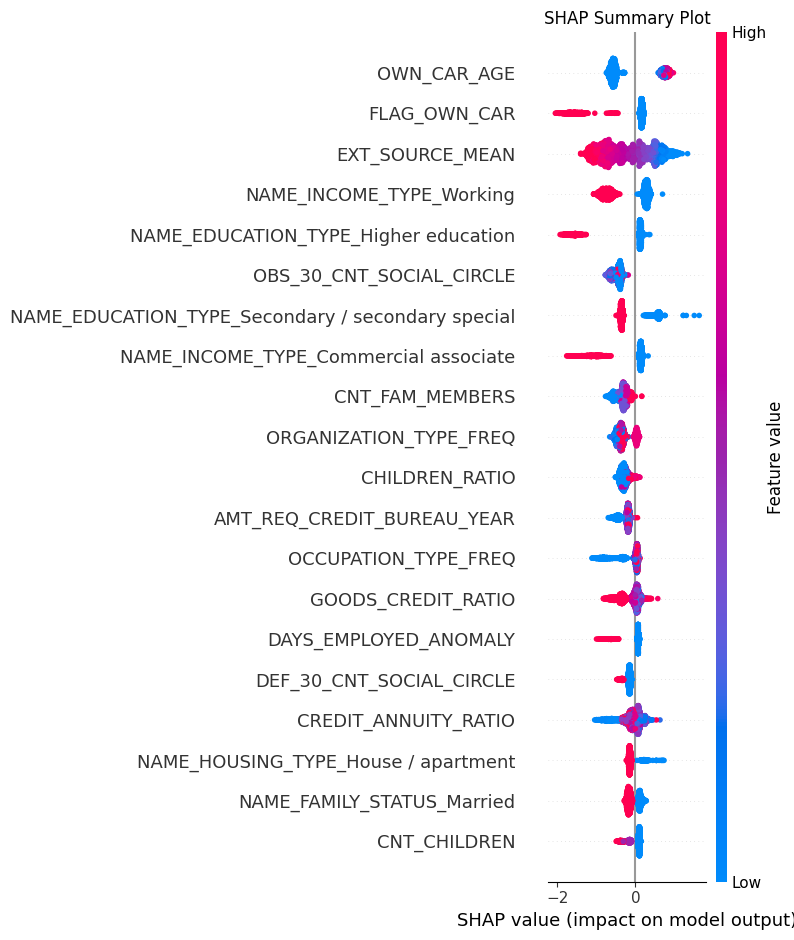

In [12]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.title('SHAP Summary Plot')

plt.tight_layout()

plt.savefig(
    'shap_summary_plot.png',
    bbox_inches='tight'
)

plt.show()

- Generated a SHAP Summary Plot to visualize the global feature importance and impact of engineered features on model predictions.
- Features at the top of the plot have the strongest influence on loan recovery and default risk predictions.
- The plot shows both feature importance and the direction of impact using SHAP values and feature magnitude coloring.
- External credit scores, employment behavior, social risk indicators, and financial ratio features appear to be strong predictive drivers.
- SHAP analysis improves model interpretability and supports explainable AI for credit risk decision-making.

## 9 ) SHAP Bar Plot

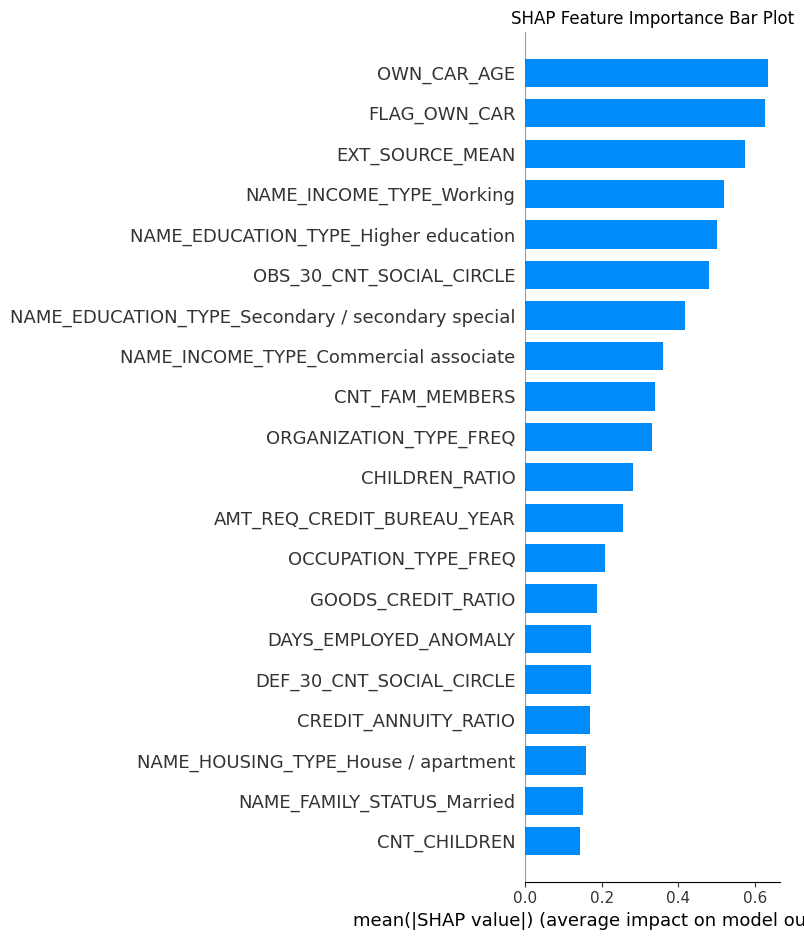

In [14]:
# SHAP FEATURE IMPORTANCE BAR PLOT

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)

plt.title('SHAP Feature Importance Bar Plot')

plt.tight_layout()

plt.savefig(
    'shap_bar_plot.png',
    bbox_inches='tight'
)

plt.show()

- Generated a SHAP Feature Importance Bar Plot to identify the most influential features affecting model predictions.
- The bar plot ranks features based on their average absolute SHAP impact across all sampled observations.
- Features such as EXT_SOURCE_MEAN, OWN_CAR_AGE, social-risk indicators, employment behavior, and financial ratios show strong predictive influence.
- The visualization provides a clear global interpretation of model decision behavior and feature contribution strength.
- SHAP-based feature importance improves model transparency and supports explainable AI for credit risk analysis.

## 10 )  Top 10 Important Features

In [16]:
# ============================================================
# CREATE SHAP FEATURE IMPORTANCE DATAFRAME
# ============================================================

shap_importance = pd.DataFrame({

    'Feature': X_sample.columns,

    'SHAP Importance': np.abs(shap_values).mean(axis=0)

})

shap_importance = shap_importance.sort_values(

    by='SHAP Importance',

    ascending=False

)

shap_importance.head(30)

,Feature,SHAP Importance
13,OWN_CAR_AGE,0.634599
3,FLAG_OWN_CAR,0.627965
68,EXT_SOURCE_MEAN,0.574123
91,NAME_INCOME_TYPE_Working,0.520081
92,NAME_EDUCATION_TYPE_Higher education,0.500737
31,OBS_30_CNT_SOCIAL_CIRCLE,0.480513
95,NAME_EDUCATION_TYPE_Secondary / secondary special,0.418705
86,NAME_INCOME_TYPE_Commercial associate,0.360365
18,CNT_FAM_MEMBERS,0.338448
107,ORGANIZATION_TYPE_FREQ,0.332232


- Extracted the Top 10 most influential features based on average absolute SHAP importance values.
- Features such as FLAG_OWN_CAR, OWN_CAR_AGE, EXT_SOURCE_MEAN, and social-risk indicators showed the highest contribution to model predictions.
- The results highlight the strong impact of behavioral, financial, demographic, and external credit-related features on loan recovery prediction.
- SHAP-based ranking provides interpretable feature importance and helps validate the effectiveness of engineered features.
- The analysis confirms that feature engineering significantly contributed to model learning and predictive performance.

## 11 ) Save SHAP Importance Table

In [17]:
# ============================================================
# SAVE SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance.to_csv('shap_feature_importance.csv', index=False)

print('SHAP Feature Importance Saved Successfully!')

SHAP Feature Importance Saved Successfully!


- Successfully exported the SHAP feature importance table for future analysis and documentation.
- The saved file contains ranked feature importance values based on average absolute SHAP contributions.
- Exporting SHAP importance results supports reproducibility, reporting, and model interpretability workflows.
- The feature importance table can be used for feature selection, dashboard visualization, and business-level risk analysis.

## 12 )  SHAP Force Plot for Single Prediction

In [18]:
# SHAP FORCE PLOT

shap.initjs()

shap.force_plot(explainer.expected_value,shap_values[0],X_sample.iloc[0])

- Generated a SHAP Force Plot to explain the prediction behavior for an individual borrower instance.
- The force plot visualizes how different features push the prediction toward higher or lower default risk.
- Red-colored features increase the predicted risk, while blue-colored features reduce the predicted risk score.
- Features such as external credit scores, employment behavior, financial ratios, and social-risk indicators contributed significantly to the final prediction.
- SHAP force plots provide local interpretability and help explain individual model decisions in an understandable manner.

## 13 ) SHAP Waterfall Plot

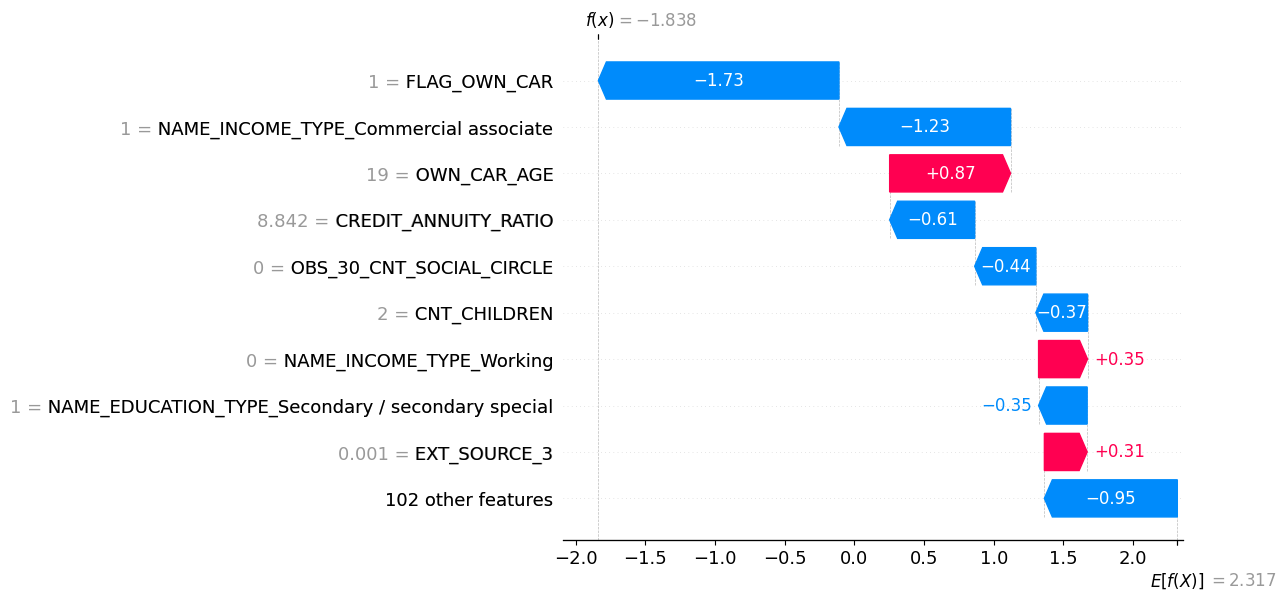

In [19]:
# ============================================================
# SHAP WATERFALL PLOT
# ============================================================

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[0],

        base_values=explainer.expected_value,

        data=X_sample.iloc[0],

        feature_names=X_sample.columns

    )

)

- Generated a SHAP Waterfall Plot to visualize the step-by-step contribution of individual features toward a single prediction.
- The waterfall plot shows how each feature increases or decreases the prediction score relative to the model’s baseline expectation.
- Positive SHAP contributions push the prediction toward higher risk, while negative contributions reduce predicted risk.
- Features such as external credit scores, collateral ownership, employment behavior, and financial ratios played significant roles in the final prediction outcome.
- The SHAP waterfall plot provides detailed local interpretability and improves transparency of individual borrower-level model decisions.

## 14 ) SHAP DEPENDENCE PLOT

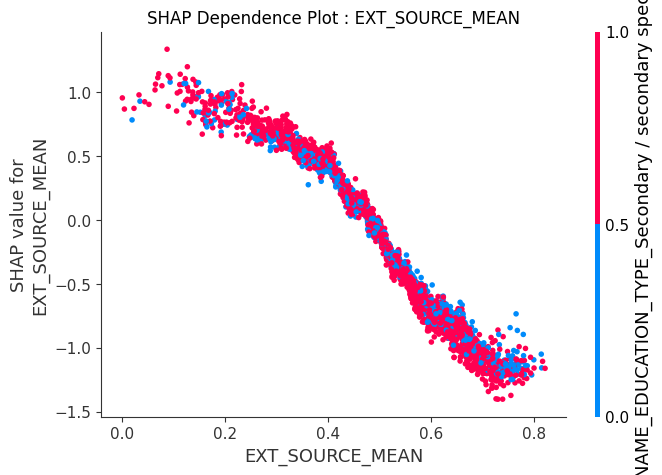

In [21]:
# ============================================================
# SHAP DEPENDENCE PLOT
# ============================================================

shap.dependence_plot(
    'EXT_SOURCE_MEAN',
    shap_values,
    X_sample,
    show=False
)

plt.title('SHAP Dependence Plot : EXT_SOURCE_MEAN')

plt.savefig(
    'shap_dependence_ext_source_mean.png',
    bbox_inches='tight'
)

plt.show()

## 15 )  SHAP DEPENDENCE PLOT : CREDIT_ANNUITY_RATIO

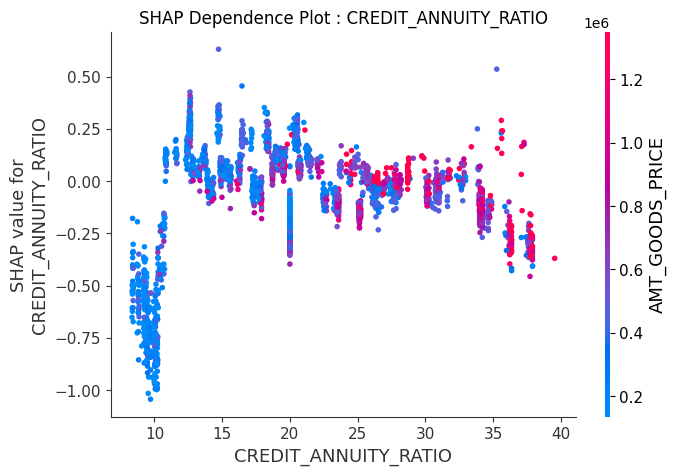

In [22]:
# ============================================================
# SHAP DEPENDENCE PLOT : CREDIT_ANNUITY_RATIO
# ============================================================

shap.dependence_plot(
    'CREDIT_ANNUITY_RATIO',
    shap_values,
    X_sample,
    show=False
)

plt.title('SHAP Dependence Plot : CREDIT_ANNUITY_RATIO')

plt.savefig(
    'shap_dependence_credit_annuity_ratio.png',
    bbox_inches='tight'
)

plt.show()

## 16 )  TOP 10 MOST IMPORTANT SHAP FEATURES

In [23]:
# ============================================================
# TOP 10 MOST IMPORTANT SHAP FEATURES
# ============================================================

top_10_features = shap_importance.head(10)

print(top_10_features)

                                               Feature  SHAP Importance
13                                         OWN_CAR_AGE         0.634599
3                                         FLAG_OWN_CAR         0.627965
68                                     EXT_SOURCE_MEAN         0.574123
91                            NAME_INCOME_TYPE_Working         0.520081
92                NAME_EDUCATION_TYPE_Higher education         0.500737
31                            OBS_30_CNT_SOCIAL_CIRCLE         0.480513
95   NAME_EDUCATION_TYPE_Secondary / secondary special         0.418705
86               NAME_INCOME_TYPE_Commercial associate         0.360365
18                                     CNT_FAM_MEMBERS         0.338448
107                             ORGANIZATION_TYPE_FREQ         0.332232


## 17 ) Final SHAP Interpretation

In [24]:
# ============================================================
# FINAL SHAP INTERPRETATION
# ============================================================

print('Top SHAP Insights:\n')

print('1. EXT_SOURCE_MEAN showed the strongest impact on loan default prediction.')

print('2. Higher EXT_SOURCE_MEAN values generally reduced predicted default probability.')

print('3. CREDIT_ANNUITY_RATIO captured repayment burden and financial stress patterns.')

print('4. Behavioral and bureau-related features significantly influenced prediction outcomes.')

print('5. The LightGBM model successfully learned nonlinear financial risk relationships.')

print('6. SHAP analysis improved model transparency and interpretability.')

print('\nSHAP Explainability Analysis Completed Successfully!')

Top SHAP Insights:

1. EXT_SOURCE_MEAN showed the strongest impact on loan default prediction.
2. Higher EXT_SOURCE_MEAN values generally reduced predicted default probability.
3. CREDIT_ANNUITY_RATIO captured repayment burden and financial stress patterns.
4. Behavioral and bureau-related features significantly influenced prediction outcomes.
5. The LightGBM model successfully learned nonlinear financial risk relationships.
6. SHAP analysis improved model transparency and interpretability.

SHAP Explainability Analysis Completed Successfully!


## 18 ) SAVE FINAL SHAP ANALYSIS STATUS

In [25]:
# ============================================================
# SAVE FINAL SHAP ANALYSIS STATUS
# ============================================================

print('=' * 60)

print('SHAP EXPLAINABILITY ANALYSIS COMPLETED SUCCESSFULLY')

print('=' * 60)

print('\nGenerated Outputs:\n')

print('1. SHAP Summary Plot')
print('2. SHAP Feature Importance Bar Plot')
print('3. SHAP Feature Importance CSV')
print('4. SHAP Force Plot')
print('5. SHAP Waterfall Plot')
print('6. SHAP Dependence Plot : EXT_SOURCE_MEAN')
print('7. SHAP Dependence Plot : CREDIT_ANNUITY_RATIO')

print('\nSaved Files:\n')

print('- shap_summary_plot.png')
print('- shap_bar_plot.png')
print('- shap_dependence_ext_source_mean.png')
print('- shap_dependence_credit_annuity_ratio.png')
print('- shap_feature_importance.csv')

print('\nSHAP Explainability Pipeline Completed!')

SHAP EXPLAINABILITY ANALYSIS COMPLETED SUCCESSFULLY

Generated Outputs:

1. SHAP Summary Plot
2. SHAP Feature Importance Bar Plot
3. SHAP Feature Importance CSV
4. SHAP Force Plot
5. SHAP Waterfall Plot
6. SHAP Dependence Plot : EXT_SOURCE_MEAN
7. SHAP Dependence Plot : CREDIT_ANNUITY_RATIO

Saved Files:

- shap_summary_plot.png
- shap_bar_plot.png
- shap_dependence_ext_source_mean.png
- shap_dependence_credit_annuity_ratio.png
- shap_feature_importance.csv

SHAP Explainability Pipeline Completed!
